In [1]:
import os
import argparse
import json
from datasets import load_from_disk
import matplotlib.pyplot as plt

import numpy as np
from scipy.stats import pearsonr

In [2]:
class SimpleArgs:
    max_source_length: int = 1024
    max_target_length: int = 128
    pad_to_max_length: bool = True
    num_beams: int = 5
    use_model_check: bool = True   
    model_name_or_path: str = "models/bart_large_step0/checkpoint-10000"
    tokenizer_name: str = None
    config_name = None
    use_fast_tokenizer = True
    output_generation: bool = True
    dataset_name = "data/fine_tuning/wikitablequestions_small"

In [3]:
with open("../logs/likelihood.json") as data:
    results = json.load(data)
    

In [4]:
for result in results:
    print(result)
    

{'question': 'which team won previous to crettyard?', 'expected_answer': ['Wolfe Tones'], 'model_answer': 'confey', 'log_likelihood': -2.5910592079162598, 'accuracy': False}
{'question': 'how many more passengers flew to los angeles than to saskatoon from manzanillo airport in 2013?', 'expected_answer': ['12,467'], 'model_answer': '', 'log_likelihood': -4.366709232330322, 'accuracy': False}
{'question': 'after winning on four credits with a full house, what is your payout?', 'expected_answer': ['32'], 'model_answer': '40', 'log_likelihood': -3.510500907897949, 'accuracy': False}
{'question': 'which players played the same position as ardo kreek?', 'expected_answer': ['Siim Ennemuist', 'Andri Aganits'], 'model_answer': 'siim ennemuist, andri aganits', 'log_likelihood': -0.2797544598579407, 'accuracy': True}
{'question': 'which athlete was from south korea after the year 2010?', 'expected_answer': ['Kim Yu-na'], 'model_answer': 'tatiana volosozhar / maxim trankov', 'log_likelihood': -0.3

In [5]:
likelihood = [result["log_likelihood"] for result in results]
accuracy = [result["accuracy"] for result in results]

In [6]:
correlation, p_value = pearsonr(likelihood, accuracy)
print(f"Pearson correlation: {correlation:.4f} (p={p_value:.4e})")

Pearson correlation: 0.6794 (p=7.7694e-15)


In [7]:
lower_thresh = np.percentile(likelihood, 10)  # bottom 10%
upper_thresh = np.percentile(likelihood, 90)  # top 10%

print(f"Lower threshold (complex): {lower_thresh}")
print(f"Upper threshold (simple): {upper_thresh}")

Lower threshold (complex): -3.417357921600342
Upper threshold (simple): -0.3400365114212036


In [8]:
total_accuracy = sum(accuracy) / len(accuracy)
print(f"Total Accuracy: {total_accuracy:.4f}")  

Total Accuracy: 0.4100


/tmp/ipykernel_3269832/2249826443.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(likelihood, shade=True)


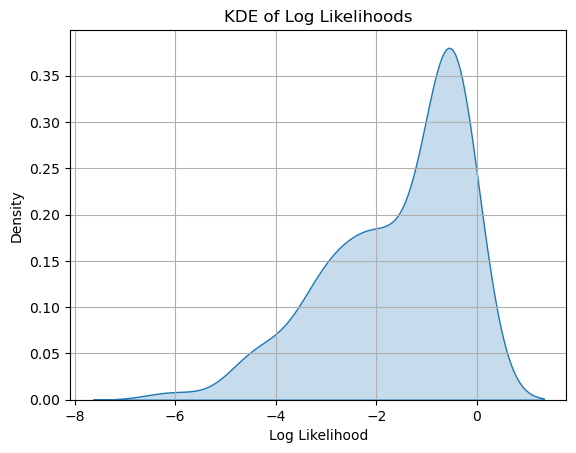

In [9]:
import seaborn as sns

sns.kdeplot(likelihood, shade=True)
plt.xlabel("Log Likelihood")
plt.title("KDE of Log Likelihoods")
plt.grid(True)
plt.show()

/tmp/ipykernel_3269832/2193628655.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(likelihood, shade=True)


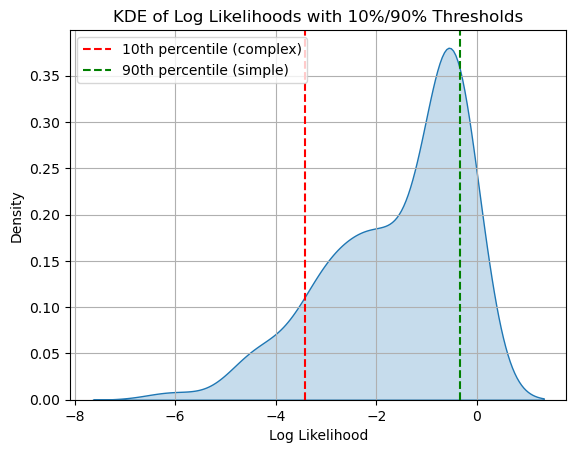

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute thresholds
lower_thresh = np.percentile(likelihood, 10)  # bottom 10%
upper_thresh = np.percentile(likelihood, 90)  # top 10%

# KDE plot
sns.kdeplot(likelihood, shade=True)
plt.axvline(lower_thresh, color='red', linestyle='--', label='10th percentile (complex)')
plt.axvline(upper_thresh, color='green', linestyle='--', label='90th percentile (simple)')

# Labels and formatting
plt.xlabel("Log Likelihood")
plt.title("KDE of Log Likelihoods with 10%/90% Thresholds")
plt.legend()
plt.grid(True)
plt.show()

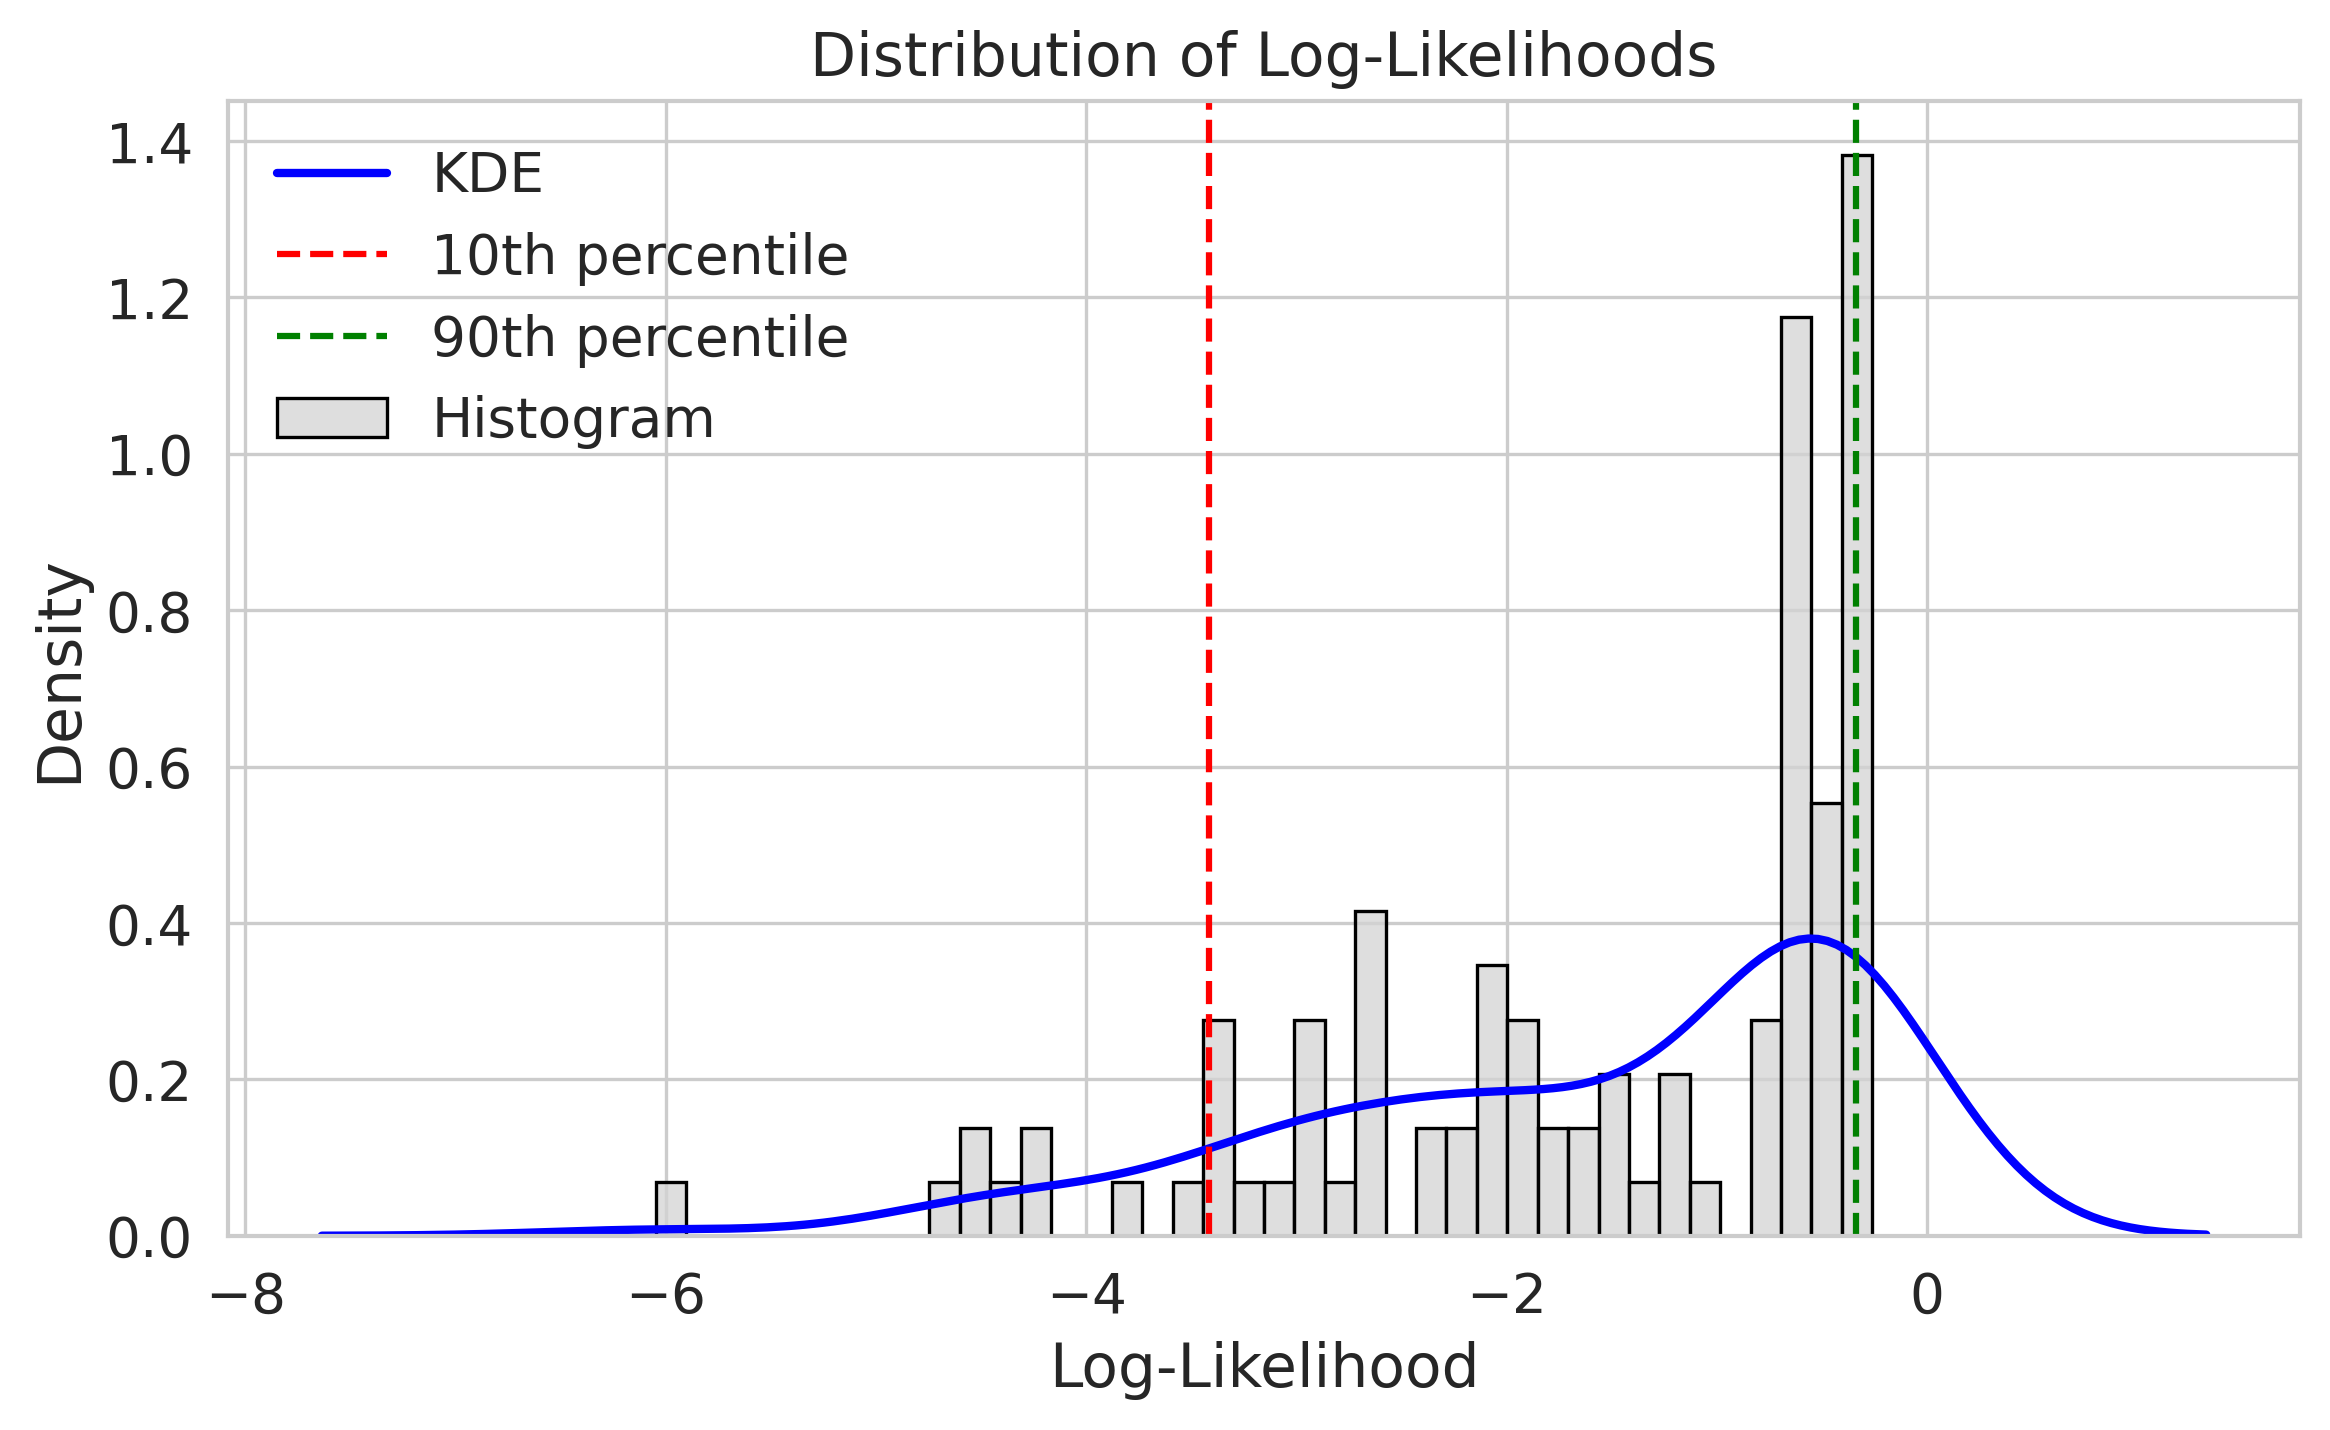

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Style for research figures
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

# Compute thresholds
lower_thresh = np.percentile(likelihood, 10)
upper_thresh = np.percentile(likelihood, 90)

# Create figure
plt.figure(figsize=(8, 5), dpi=300)

# Plot histogram (normalized density)
sns.histplot(
    likelihood,
    bins=40,
    kde=False,
    stat="density",
    color="lightgray",
    edgecolor="black",
    label="Histogram"
)

# Overlay KDE
sns.kdeplot(
    likelihood,
    color="blue",
    linewidth=2,
    label="KDE"
)

# Thresholds
plt.axvline(lower_thresh, color='red', linestyle='--', linewidth=1.5, label='10th percentile')
plt.axvline(upper_thresh, color='green', linestyle='--', linewidth=1.5, label='90th percentile')

# Axis labels
plt.xlabel("Log-Likelihood")
plt.ylabel("Density")
plt.title("Distribution of Log-Likelihoods")

# Legend and layout
plt.legend(frameon=False)
plt.tight_layout()

# Optional: Save figure (for paper)
plt.savefig("../logs/plots/log_likelihood_distribution.png", bbox_inches='tight', dpi=300)

plt.show()